# **Deteksi Gesture Suit Jawa dengan MediaPipe Hand Landmarker + Deep Learning MLP**

Notebook ini berisi alur lengkap dari awal sampai akhir untuk membuat model deteksi gesture **Suit Jawa**:

- **Gajah** = ibu jari / jempol
- **Orang** = telunjuk
- **Semut** = kelingking

Pendekatan yang digunakan:

1. **MediaPipe Hand Landmarker** untuk mendeteksi 21 titik landmark tangan.
2. Landmark tangan diubah menjadi **63 fitur**: `21 titik × 3 koordinat (x, y, z)`.
3. Fitur landmark digunakan sebagai input model **Deep Learning MLP / Multi-Layer Perceptron**.
4. Model memprediksi kelas: `gajah`, `orang`, atau `semut`.
5. Model dievaluasi, disimpan, dan diuji dengan gambar baru.

> Catatan: MediaPipe digunakan sebagai ekstraksi fitur landmark tangan, sedangkan model Deep Learning-nya adalah MLP yang dilatih menggunakan dataset landmark.

## **Tahap 1 — Install Library**

Pada tahap ini kita menginstal library yang dibutuhkan:

- `mediapipe` untuk mendeteksi landmark tangan.
- `tensorflow` untuk membuat dan melatih model MLP.
- `scikit-learn` untuk split data, class weight, dan evaluasi.
- `seaborn` dan `matplotlib` untuk visualisasi hasil evaluasi.

In [1]:
!pip install -q mediapipe scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00


## **Tahap 2 — Mount Google Drive dan Konfigurasi Path**

Notebook ini memakai Google Drive sebagai lokasi penyimpanan dataset dan model.

Struktur folder yang digunakan:

```text
MyDrive/
  suit_jawa/
    dataset_raw/
      gajah/
      orang/
      semut/
    testing/
      test_gajah.jpg
      test_orang.jpg
      test_semut.jpg
```

Output yang akan dibuat:

```text
suit_jawa/
  landmark_dataset.csv
  failed_landmark_images.csv
  best_model_mediapipe_mlp.keras
  model_final_mediapipe_mlp.keras
  realtime_suit_jawa_mediapipe.py
```

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import random
import numpy as np
import tensorflow as tf

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Konfigurasi utama
PROJECT_DIR = "/content/drive/MyDrive/suit_jawa"
RAW_DATASET_DIR = os.path.join(PROJECT_DIR, "dataset_raw")
TESTING_DIR = os.path.join(PROJECT_DIR, "testing")

LANDMARK_TASK_PATH = "hand_landmarker.task"
LANDMARK_CSV_PATH = os.path.join(PROJECT_DIR, "landmark_dataset.csv")
FAILED_IMAGES_CSV_PATH = os.path.join(PROJECT_DIR, "failed_landmark_images.csv")

BEST_MODEL_PATH = os.path.join(PROJECT_DIR, "best_model_mediapipe_mlp.keras")
FINAL_MODEL_PATH = os.path.join(PROJECT_DIR, "model_final_mediapipe_mlp.keras")

CLASS_NAMES = ["gajah", "orang", "semut"]
LABEL_TO_ID = {"gajah": 0, "orang": 1, "semut": 2}
ID_TO_LABEL = {0: "gajah", 1: "orang", 2: "semut"}

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DATASET_DIR:", RAW_DATASET_DIR)
print("TESTING_DIR:", TESTING_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/suit_jawa
RAW_DATASET_DIR: /content/drive/MyDrive/suit_jawa/dataset_raw
TESTING_DIR: /content/drive/MyDrive/suit_jawa/testing


## **Tahap 3 — Cek Dataset Gambar Awal**

Sebelum landmark diekstrak, kita cek dulu apakah folder dataset sudah benar dan berapa jumlah gambar pada setiap kelas.

Tujuan tahap ini:

- Memastikan folder `gajah`, `orang`, dan `semut` ada.
- Mengecek jumlah data tiap kelas.
- Menghindari error karena path dataset salah.

In [8]:
import os
from collections import Counter

def list_image_files(folder):
    return [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

if not os.path.exists(RAW_DATASET_DIR):
    raise FileNotFoundError(f"Folder dataset tidak ditemukan: {RAW_DATASET_DIR}")

print("Folder dataset:", RAW_DATASET_DIR)
print("Isi folder:", os.listdir(RAW_DATASET_DIR))

raw_counts = {}

for label in CLASS_NAMES:
    folder = os.path.join(RAW_DATASET_DIR, label)

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder kelas tidak ditemukan: {folder}")

    images = list_image_files(folder)
    raw_counts[label] = len(images)
    print(f"{label}: {len(images)} gambar")

print("Total gambar:", sum(raw_counts.values()))

Folder dataset: /content/drive/MyDrive/suit_jawa/dataset_raw
Isi folder: ['semut', 'orang', 'gajah']
gajah: 198 gambar
orang: 231 gambar
semut: 140 gambar
Total gambar: 569


## **Tahap 4 — Preview Dataset Secara Acak**

Tahap ini digunakan untuk mengecek kualitas dataset secara visual.

Dataset yang baik untuk metode landmark harus memenuhi syarat:

- Tangan terlihat jelas.
- Gesture tidak ambigu.
- Jari utama terlihat jelas.
- Tidak blur parah.
- Tidak ada gambar kosong.

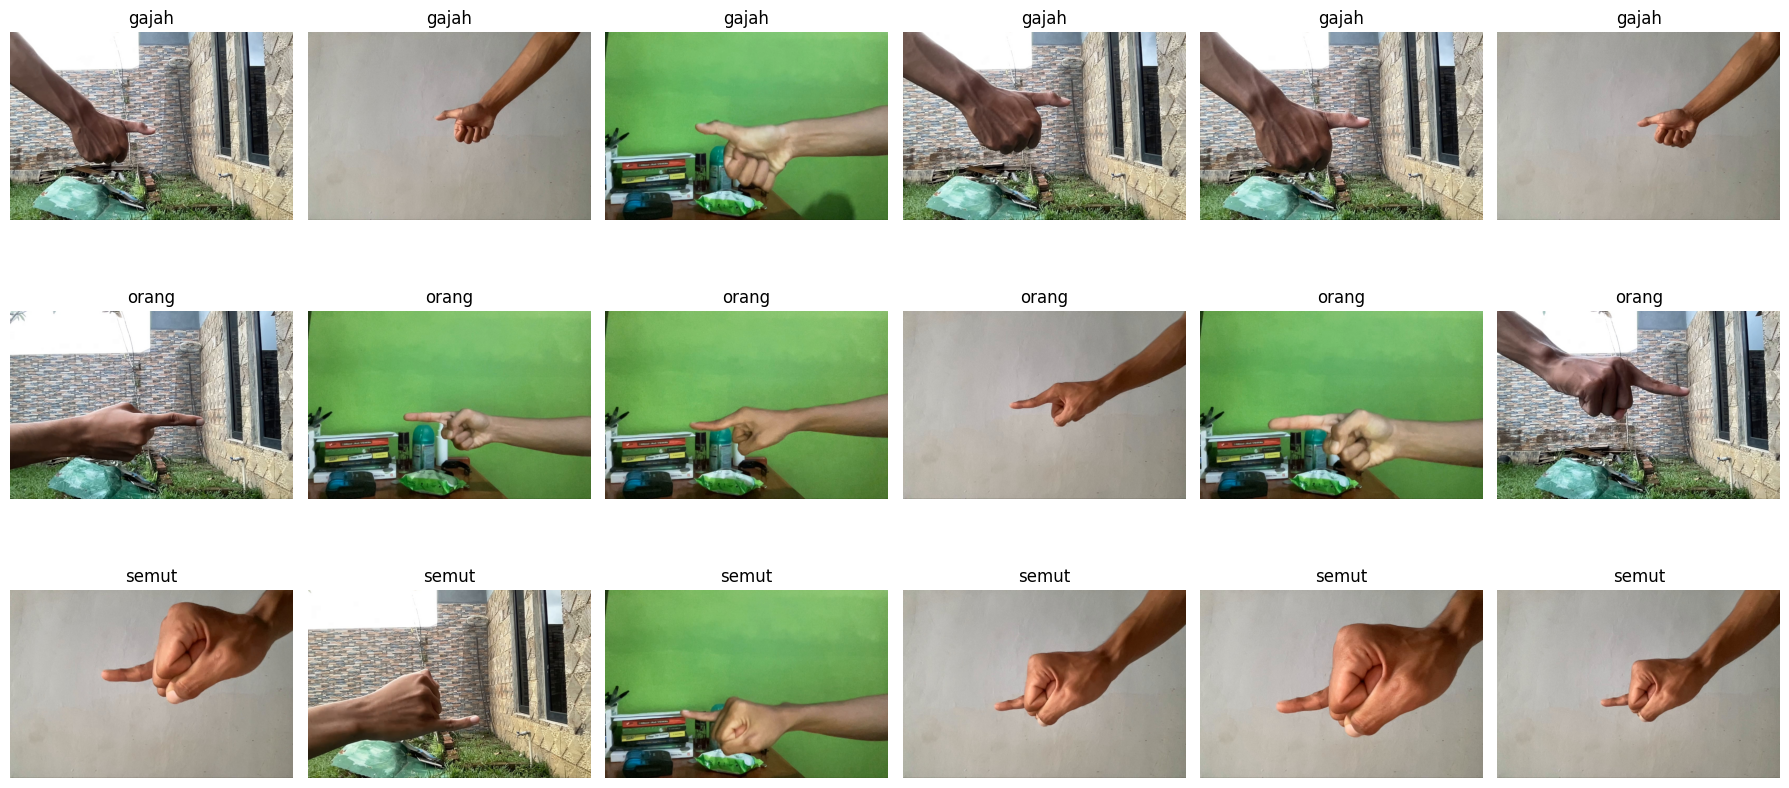

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

def preview_random_images(raw_dir, labels, samples_per_class=6):
    plt.figure(figsize=(3 * samples_per_class, 9))
    index = 1

    for label in labels:
        folder = os.path.join(raw_dir, label)
        images = list_image_files(folder)

        if len(images) == 0:
            continue

        sample_images = random.sample(images, min(samples_per_class, len(images)))

        for img_name in sample_images:
            img_path = os.path.join(folder, img_name)
            img = Image.open(img_path)

            plt.subplot(len(labels), samples_per_class, index)
            plt.imshow(img)
            plt.title(label)
            plt.axis("off")
            index += 1

    plt.tight_layout()
    plt.show()

preview_random_images(RAW_DATASET_DIR, CLASS_NAMES, samples_per_class=6)

## **Tahap 5 — Download Model MediaPipe Hand Landmarker**

MediaPipe versi baru menggunakan **Tasks API**, sehingga kita membutuhkan file:

```text
hand_landmarker.task
```

File ini digunakan untuk mendeteksi 21 landmark tangan pada gambar.

In [10]:
import os

if not os.path.exists(LANDMARK_TASK_PATH):
    !wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

print("Hand landmarker tersedia:", os.path.exists(LANDMARK_TASK_PATH))
print("Path:", LANDMARK_TASK_PATH)

Hand landmarker tersedia: True
Path: hand_landmarker.task


## **Tahap 6 — Definisi Fungsi Ekstraksi Landmark**

Pada tahap ini kita membuat fungsi untuk mengubah landmark tangan menjadi fitur numerik.

MediaPipe menghasilkan 21 titik tangan. Setiap titik punya koordinat:

```text
x, y, z
```

Sehingga total fitur:

```text
21 × 3 = 63 fitur
```

Agar lebih stabil, fitur dinormalisasi:

1. Titik wrist/pergelangan tangan digunakan sebagai pusat.
2. Semua titik dikurangi koordinat wrist.
3. Skala dinormalisasi dengan jarak maksimum dari wrist ke titik lain pada sumbu x-y.

In [11]:
import cv2
import csv
import pandas as pd
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def landmarks_to_features(hand_landmarks):
    coords = np.array(
        [[lm.x, lm.y, lm.z] for lm in hand_landmarks],
        dtype=np.float32
    )

    # Gunakan wrist / pergelangan tangan sebagai pusat koordinat
    wrist = coords[0]
    coords = coords - wrist

    # Normalisasi skala berdasarkan jarak maksimum dari wrist
    scale = np.max(np.linalg.norm(coords[:, :2], axis=1))
    if scale < 1e-6:
        scale = 1.0

    coords = coords / scale

    return coords.flatten()


def create_image_hand_landmarker():
    # Membuat detector MediaPipe Hand Landmarker untuk gambar statis.
    base_options = python.BaseOptions(model_asset_path=LANDMARK_TASK_PATH)

    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5
    )

    return vision.HandLandmarker.create_from_options(options)

print("Fungsi ekstraksi landmark siap digunakan.")

Fungsi ekstraksi landmark siap digunakan.


## **Tahap 7 — Ekstraksi Landmark ke CSV**

Pada tahap ini semua gambar pada folder `dataset_raw` akan diproses oleh MediaPipe.

Output utama:

```text
landmark_dataset.csv
```

Isi CSV:

```text
f0, f1, ..., f62, label
```

Jika ada gambar yang gagal dideteksi tangan, path gambar tersebut disimpan ke:

```text
failed_landmark_images.csv
```

In [12]:
rows = []
failed_images = []

detector = create_image_hand_landmarker()

for label in CLASS_NAMES:
    folder = os.path.join(RAW_DATASET_DIR, label)
    image_files = list_image_files(folder)

    print(f"Memproses kelas {label}: {len(image_files)} gambar")

    for img_name in image_files:
        img_path = os.path.join(folder, img_name)

        image_bgr = cv2.imread(img_path)
        if image_bgr is None:
            failed_images.append([img_path, label, "gagal dibaca"])
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=image_rgb
        )

        result = detector.detect(mp_image)

        if len(result.hand_landmarks) == 0:
            failed_images.append([img_path, label, "tangan tidak terdeteksi"])
            continue

        hand_landmarks = result.hand_landmarks[0]
        features = landmarks_to_features(hand_landmarks)

        rows.append(list(features) + [label])

detector.close()

# Simpan dataset landmark
header = [f"f{i}" for i in range(63)] + ["label"]

with open(LANDMARK_CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

# Simpan daftar gambar gagal
with open(FAILED_IMAGES_CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image_path", "label", "reason"])
    writer.writerows(failed_images)

print("Jumlah data landmark berhasil:", len(rows))
print("Jumlah gambar gagal dideteksi:", len(failed_images))
print("CSV landmark tersimpan di:", LANDMARK_CSV_PATH)
print("CSV gagal deteksi tersimpan di:", FAILED_IMAGES_CSV_PATH)

Memproses kelas gajah: 198 gambar
Memproses kelas orang: 231 gambar
Memproses kelas semut: 140 gambar
Jumlah data landmark berhasil: 561
Jumlah gambar gagal dideteksi: 8
CSV landmark tersimpan di: /content/drive/MyDrive/suit_jawa/landmark_dataset.csv
CSV gagal deteksi tersimpan di: /content/drive/MyDrive/suit_jawa/failed_landmark_images.csv


## **Tahap 8 — Cek Dataset Landmark**

Setelah landmark tersimpan, kita cek jumlah data per kelas.

Jika kelas tertentu terlalu sedikit, misalnya `semut` jauh lebih kecil, nanti akan dibantu dengan `class_weight` saat training.

In [13]:
df = pd.read_csv(LANDMARK_CSV_PATH)

print("Shape dataset landmark:", df.shape)
print("\nJumlah data per kelas:")
print(df["label"].value_counts())

display(df.head())

Shape dataset landmark: (561, 64)

Jumlah data per kelas:
label
orang    231
gajah    198
semut    132
Name: count, dtype: int64


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f54,f55,f56,f57,f58,f59,f60,f61,f62,label
0,0.0,0.0,0.0,-0.259110,-0.098524,-0.095350,-0.579291,0.026699,-0.128522,-0.812651,...,-0.157810,0.710811,-0.169193,-0.136259,0.522957,-0.145568,-0.102625,0.491586,-0.118593,gajah
1,0.0,0.0,0.0,0.300628,-0.035405,-0.005679,0.561729,0.014345,-0.061726,0.795270,...,0.146898,0.891549,-0.052974,0.106654,0.774559,-0.011179,0.080331,0.647844,0.002095,gajah
2,0.0,0.0,0.0,0.240532,-0.022036,-0.017749,0.518130,0.064288,-0.111105,0.738776,...,0.106148,0.826560,-0.359862,0.055062,0.685546,-0.302250,0.074629,0.519021,-0.275453,gajah
3,0.0,0.0,0.0,-0.250469,-0.100594,-0.116561,-0.568398,-0.114069,-0.158766,-0.808169,...,-0.191386,0.741648,-0.139174,-0.164511,0.606363,-0.116328,-0.173712,0.542578,-0.090687,gajah
4,0.0,0.0,0.0,-0.249494,-0.113413,-0.104036,-0.578862,-0.059116,-0.131770,-0.822866,...,-0.119323,0.787397,-0.108600,-0.101068,0.609698,-0.080501,-0.107127,0.496761,-0.048904,gajah


## **Tahap 9 — Visualisasi Distribusi Kelas**

Visualisasi ini membantu melihat apakah dataset landmark seimbang atau tidak.

Dataset tidak harus seimbang sempurna, tetapi jika ada selisih besar, gunakan `class_weight`.

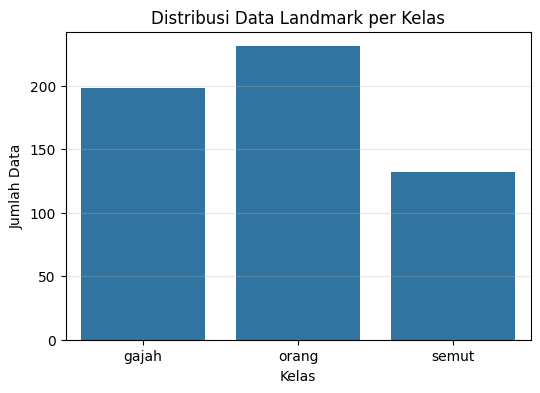

In [14]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", order=CLASS_NAMES)
plt.title("Distribusi Data Landmark per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.grid(axis="y", alpha=0.3)
plt.show()

## **Tahap 10 — Menyiapkan Fitur dan Label**

Pada tahap ini:

- Kolom `f0` sampai `f62` dijadikan fitur `X`.
- Kolom `label` dijadikan target `y`.
- Label diubah menjadi angka:
  - `gajah = 0`
  - `orang = 1`
  - `semut = 2`

In [15]:
X = df.drop("label", axis=1).values.astype("float32")
y = df["label"].map(LABEL_TO_ID).values.astype("int64")

print("X shape:", X.shape)
print("y shape:", y.shape)

if X.shape[1] != 63:
    raise ValueError(f"Jumlah fitur harus 63, tetapi ditemukan {X.shape[1]}")

X shape: (561, 63)
y shape: (561,)


## **Tahap 11 — Split Data Train, Validation, dan Test**

Data dibagi menjadi:

- **70% train**
- **15% validation**
- **15% test**

Kita memakai `stratify`, supaya proporsi kelas tetap mirip pada setiap split.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain label count:", np.bincount(y_train))
print("Validation label count:", np.bincount(y_val))
print("Test label count:", np.bincount(y_test))

Train: (392, 63)
Validation: (84, 63)
Test: (85, 63)

Train label count: [138 162  92]
Validation label count: [30 34 20]
Test label count: [30 35 20]


## **Tahap 12 — Membuat Class Weight**

Karena jumlah data setiap kelas tidak selalu sama, `class_weight` digunakan agar model tetap memperhatikan kelas yang datanya lebih sedikit.

Contoh:
- Jika `semut` lebih sedikit, bobot kelas `semut` akan lebih besar.

In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    int(i): float(weight)
    for i, weight in enumerate(class_weights_array)
}

print("Class weight:", class_weight)

for idx, weight in class_weight.items():
    print(f"{ID_TO_LABEL[idx]}: {weight:.4f}")

Class weight: {0: 0.9468599033816425, 1: 0.8065843621399177, 2: 1.4202898550724639}
gajah: 0.9469
orang: 0.8066
semut: 1.4203


## **Tahap 13 — Membuat Model Deep Learning MLP**

Model yang digunakan adalah **Multi-Layer Perceptron (MLP)**.

Input model:

```text
63 fitur landmark tangan
```

Output model:

```text
3 kelas: gajah, orang, semut
```

Arsitektur umum:

```text
Input 63 fitur
↓
Normalization
↓
Dense 128
↓
BatchNormalization
↓
Dropout
↓
Dense 64
↓
BatchNormalization
↓
Dropout
↓
Dense 32
↓
Dense 3 Softmax
```

In [18]:
from tensorflow.keras import layers, models

num_classes = len(CLASS_NAMES)

normalizer = layers.Normalization()
normalizer.adapt(X_train)

model = models.Sequential([
    layers.Input(shape=(63,)),
    normalizer,

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 63)             │           127 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,522 (76.26 KB)

 Trainable params: 19,011 (74.26 KB)

 Non-trainable params: 511 (2.00 KB)

## **Tahap 14 — Training Model**

Pada tahap training, digunakan beberapa callback:

1. **ModelCheckpoint**  
   Menyimpan model terbaik berdasarkan `val_accuracy`.

2. **EarlyStopping**  
   Menghentikan training jika model tidak membaik lagi.

3. **ReduceLROnPlateau**  
   Menurunkan learning rate jika validasi loss tidak membaik.

Training menggunakan `class_weight` agar kelas dengan data lebih sedikit tetap diperhatikan.

In [19]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5012 - loss: 1.5606
Epoch 1: val_accuracy improved from None to 0.80952, saving model to /content/drive/MyDrive/suit_jawa/best_model_mediapipe_mlp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/suit_jawa/best_model_mediapipe_mlp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.5995 - loss: 1.2335 - val_accuracy: 0.8095 - val_loss: 0.7567 - learning_rate: 0.0010
Epoch 2/150
19/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7783 - loss: 0.5385 
Epoch 2: val_accuracy improved from 0.80952 to 0.82143, saving model to /content/drive/MyDrive/suit_jawa/best_model_mediapipe_mlp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/suit_jawa/best_model_mediapipe_mlp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8061 - loss: 0.4931 - val_accuracy: 0.8214 - val_loss: 0.6160 - learning_rate: 0.0010
Epoch 3/150
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8915 - loss: 

## **Tahap 15 — Grafik Akurasi dan Loss**

Grafik ini digunakan untuk melihat proses belajar model.

Yang diharapkan:

- Akurasi training dan validation naik.
- Loss training dan validation turun.
- Tidak ada jarak terlalu besar antara training dan validation.

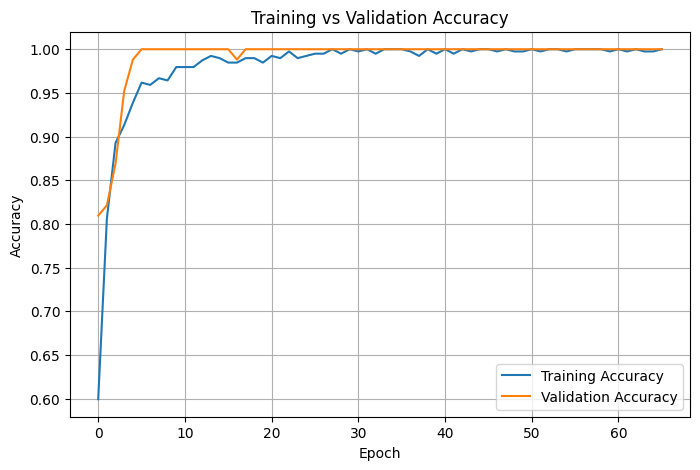

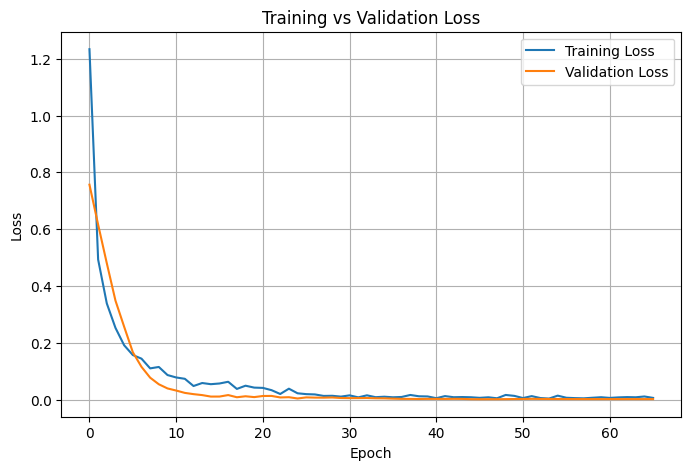

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## **Tahap 16 — Evaluasi Model pada Test Set**

Pada tahap ini, model terbaik dari file `best_model_mediapipe_mlp.keras` dimuat ulang, lalu diuji pada data test.

Metrik yang dilihat:

- Test Loss
- Test Accuracy

In [21]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_acc = best_model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Accuracy (%):", test_acc * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 1.0000 - loss: 0.1524
Test Loss: 0.15240147709846497
Test Accuracy: 1.0
Test Accuracy (%): 100.0


## **Tahap 17 — Confusion Matrix dan Classification Report**

Confusion matrix digunakan untuk melihat kelas mana yang masih sering tertukar.

Classification report menampilkan:

- Precision
- Recall
- F1-score
- Support

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step


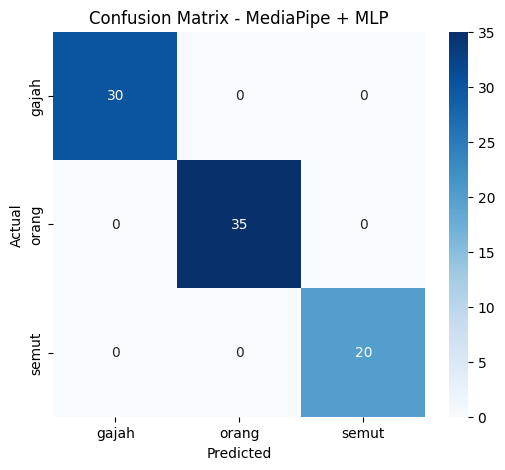

              precision    recall  f1-score   support

       gajah       1.00      1.00      1.00        30
       orang       1.00      1.00      1.00        35
       semut       1.00      1.00      1.00        20

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85



In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MediaPipe + MLP")
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## **Tahap 18 — Simpan Model Final**

Jika hasil evaluasi sudah baik, model terbaik disimpan sebagai model final:

```text
model_final_mediapipe_mlp.keras
```

File ini yang digunakan untuk testing gambar baru dan real-time webcam.

In [23]:
best_model.save(FINAL_MODEL_PATH)

print("Model final berhasil disimpan di:")
print(FINAL_MODEL_PATH)

Model final berhasil disimpan di:
/content/drive/MyDrive/suit_jawa/model_final_mediapipe_mlp.keras


## **Tahap 19 — Testing Foto Baru dari Folder `testing`**

Tahap ini menguji model pada gambar baru yang tidak masuk proses training.

Folder yang digunakan:

```text
/content/drive/MyDrive/suit_jawa/testing
```

Contoh isi folder:

```text
test_gajah.jpg
test_orang.jpg
test_semut.jpg
```

In [24]:
def predict_image_with_landmarker(img_path, model, detector):
    image_bgr = cv2.imread(img_path)

    if image_bgr is None:
        return {
            "file": os.path.basename(img_path),
            "image": None,
            "status": "Gambar gagal dibaca",
            "prediction": None,
            "confidence": 0.0,
            "scores": None
        }

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    result = detector.detect(mp_image)

    if len(result.hand_landmarks) == 0:
        return {
            "file": os.path.basename(img_path),
            "image": image_rgb,
            "status": "Tangan tidak terdeteksi",
            "prediction": None,
            "confidence": 0.0,
            "scores": None
        }

    features = landmarks_to_features(result.hand_landmarks[0])
    features = np.expand_dims(features, axis=0)

    pred = model.predict(features, verbose=0)[0]
    pred_idx = int(np.argmax(pred))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(pred[pred_idx] * 100)

    return {
        "file": os.path.basename(img_path),
        "image": image_rgb,
        "status": "Tangan terdeteksi",
        "prediction": pred_class,
        "confidence": confidence,
        "scores": pred
    }


if not os.path.exists(TESTING_DIR):
    raise FileNotFoundError(f"Folder testing tidak ditemukan: {TESTING_DIR}")

image_files = [
    file for file in os.listdir(TESTING_DIR)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Jumlah gambar testing:", len(image_files))
print(image_files)

test_detector = create_image_hand_landmarker()
results = []

for file_name in image_files:
    img_path = os.path.join(TESTING_DIR, file_name)
    result = predict_image_with_landmarker(img_path, best_model, test_detector)
    results.append(result)

    print("=" * 60)
    print("File:", result["file"])
    print("Status:", result["status"])

    if result["prediction"] is not None:
        print("Prediksi:", result["prediction"])
        print("Confidence:", f"{result['confidence']:.2f}%")
        print("Detail confidence:")
        for class_name, score in zip(CLASS_NAMES, result["scores"]):
            print(f"  {class_name}: {score * 100:.2f}%")
    else:
        print("Prediksi: -")

test_detector.close()

Jumlah gambar testing: 3
['test_orang.jpg', 'test_semut.jpg', 'test_gajah.jpg']
File: test_orang.jpg
Status: Tangan terdeteksi
Prediksi: orang
Confidence: 74.69%
Detail confidence:
  gajah: 3.89%
  orang: 74.69%
  semut: 21.42%
File: test_semut.jpg
Status: Tangan terdeteksi
Prediksi: semut
Confidence: 89.22%
Detail confidence:
  gajah: 0.06%
  orang: 10.73%
  semut: 89.22%
File: test_gajah.jpg
Status: Tangan terdeteksi
Prediksi: gajah
Confidence: 97.65%
Detail confidence:
  gajah: 97.65%
  orang: 2.10%
  semut: 0.26%


## **Tahap 20 — Visualisasi Hasil Testing Foto Baru**

Tahap ini menampilkan semua gambar testing beserta prediksi dan confidence model.

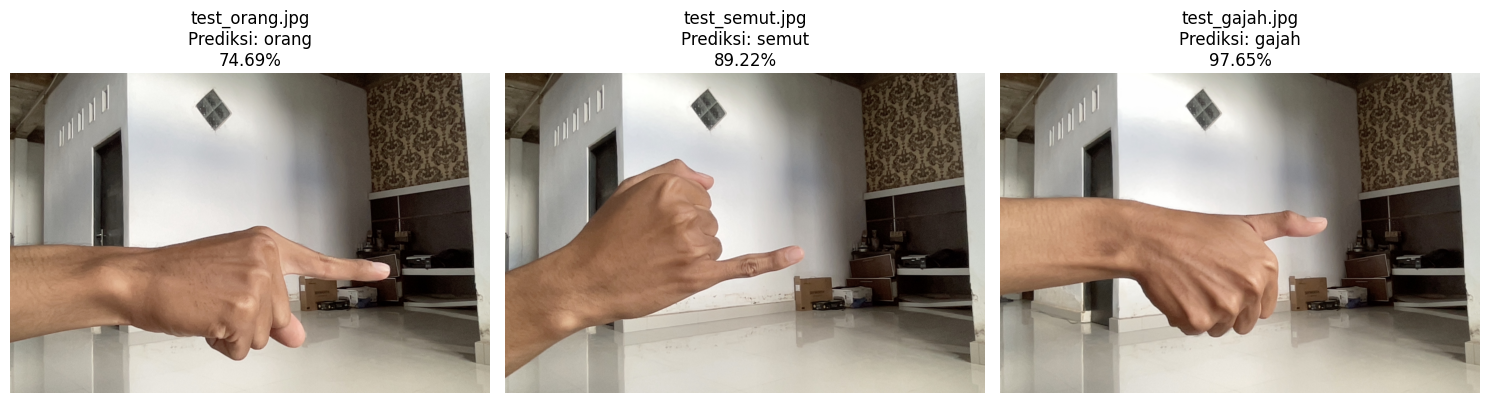

In [25]:
if len(results) > 0:
    plt.figure(figsize=(5 * len(results), 5))

    for i, result in enumerate(results):
        plt.subplot(1, len(results), i + 1)

        if result["image"] is not None:
            plt.imshow(result["image"])
        else:
            plt.text(0.5, 0.5, "Gambar tidak terbaca", ha="center", va="center")

        plt.axis("off")

        if result["prediction"] is not None:
            title = (
                f"{result['file']}\n"
                f"Prediksi: {result['prediction']}\n"
                f"{result['confidence']:.2f}%"
            )
        else:
            title = (
                f"{result['file']}\n"
                f"{result['status']}"
            )

        plt.title(title)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada gambar testing yang ditemukan.")

## **Tahap 21 — Membuat Script Real-Time Webcam untuk Laptop Lokal**

Google Colab kurang cocok untuk real-time webcam OpenCV.

Karena itu, tahap ini membuat file Python:

```text
realtime_suit_jawa_mediapipe.py
```

File ini bisa dijalankan di laptop lokal dengan perintah:

```bash
python realtime_suit_jawa_mediapipe.py
```

Pastikan di folder yang sama ada:

```text
model_final_mediapipe_mlp.keras
hand_landmarker.task
```

In [26]:
REALTIME_SCRIPT_PATH = os.path.join(PROJECT_DIR, "realtime_suit_jawa_mediapipe.py")

realtime_code = r"""
import os
import cv2
import time
import numpy as np
import tensorflow as tf
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision


MODEL_PATH = "model_final_mediapipe_mlp.keras"
HAND_LANDMARKER_PATH = "hand_landmarker.task"
CLASS_NAMES = ["gajah", "orang", "semut"]
CONFIDENCE_THRESHOLD = 70.0


HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17)
]


def landmarks_to_features(hand_landmarks):
    coords = np.array(
        [[lm.x, lm.y, lm.z] for lm in hand_landmarks],
        dtype=np.float32
    )

    wrist = coords[0]
    coords = coords - wrist

    scale = np.max(np.linalg.norm(coords[:, :2], axis=1))
    if scale < 1e-6:
        scale = 1.0

    coords = coords / scale

    return coords.flatten()


def predict_gesture(model, hand_landmarks):
    features = landmarks_to_features(hand_landmarks)
    features = np.expand_dims(features, axis=0)

    pred = model.predict(features, verbose=0)[0]
    idx = int(np.argmax(pred))

    gesture = CLASS_NAMES[idx]
    confidence = float(pred[idx] * 100)

    return gesture, confidence, pred


def determine_winner(g1, g2):
    if g1 == g2:
        return "Seri"

    rules = {
        "gajah": "orang",
        "orang": "semut",
        "semut": "gajah"
    }

    if rules[g1] == g2:
        return "Pemain 1 Menang"
    return "Pemain 2 Menang"


def draw_hand(frame, hand_landmarks, label_text):
    h, w, _ = frame.shape

    points = []
    for lm in hand_landmarks:
        x = int(lm.x * w)
        y = int(lm.y * h)
        points.append((x, y))

    for start, end in HAND_CONNECTIONS:
        cv2.line(frame, points[start], points[end], (0, 255, 0), 2)

    for x, y in points:
        cv2.circle(frame, (x, y), 4, (0, 255, 255), -1)

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    padding = 20
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(w, x_max + padding)
    y_max = min(h, y_max + padding)

    cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
    cv2.putText(
        frame,
        label_text,
        (x_min, max(30, y_min - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )


def main():
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Model tidak ditemukan: {MODEL_PATH}. "
            "Pastikan file model_final_mediapipe_mlp.keras berada di folder yang sama."
        )

    if not os.path.exists(HAND_LANDMARKER_PATH):
        raise FileNotFoundError(
            f"File tidak ditemukan: {HAND_LANDMARKER_PATH}. "
            "Download dengan perintah: "
            "curl -L -o hand_landmarker.task "
            "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
        )

    model = tf.keras.models.load_model(MODEL_PATH)

    base_options = python.BaseOptions(model_asset_path=HAND_LANDMARKER_PATH)
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )

    detector = vision.HandLandmarker.create_from_options(options)

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        raise RuntimeError(
            "Kamera tidak bisa dibuka. "
            "Jika memakai kamera eksternal, coba ubah cv2.VideoCapture(0) menjadi cv2.VideoCapture(1)."
        )

    start_time = time.time()

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Frame kamera gagal dibaca.")
            break

        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        timestamp_ms = int((time.time() - start_time) * 1000)
        result = detector.detect_for_video(mp_image, timestamp_ms)

        detected_hands = []

        if result.hand_landmarks:
            for hand_landmarks in result.hand_landmarks:
                gesture, confidence, scores = predict_gesture(model, hand_landmarks)

                xs = [lm.x for lm in hand_landmarks]
                cx = float(np.mean(xs))

                detected_hands.append({
                    "gesture": gesture,
                    "confidence": confidence,
                    "scores": scores,
                    "landmarks": hand_landmarks,
                    "cx": cx
                })

        detected_hands = sorted(detected_hands, key=lambda item: item["cx"])

        if len(detected_hands) == 0:
            result_text = "Tangan tidak terdeteksi"
        elif len(detected_hands) == 1:
            result_text = "Tunjukkan 2 tangan"
        else:
            hand1 = detected_hands[0]
            hand2 = detected_hands[1]

            if hand1["confidence"] >= CONFIDENCE_THRESHOLD and hand2["confidence"] >= CONFIDENCE_THRESHOLD:
                result_text = determine_winner(hand1["gesture"], hand2["gesture"])
            else:
                result_text = "Gesture belum jelas"

        for i, hand in enumerate(detected_hands):
            player = f"Pemain {i + 1}"

            if hand["confidence"] >= CONFIDENCE_THRESHOLD:
                label_text = f"{player}: {hand['gesture']} {hand['confidence']:.1f}%"
            else:
                label_text = f"{player}: Tidak yakin {hand['confidence']:.1f}%"

            draw_hand(frame, hand["landmarks"], label_text)

        cv2.putText(
            frame,
            result_text,
            (30, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            3
        )

        cv2.putText(
            frame,
            "Tekan Q untuk keluar",
            (30, h - 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        cv2.imshow("Suit Jawa - MediaPipe + MLP", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    detector.close()


if __name__ == "__main__":
    main()
"""

with open(REALTIME_SCRIPT_PATH, "w", encoding="utf-8") as f:
    f.write(realtime_code)

print("Script real-time berhasil dibuat di:")
print(REALTIME_SCRIPT_PATH)

Script real-time berhasil dibuat di:
/content/drive/MyDrive/suit_jawa/realtime_suit_jawa_mediapipe.py


## **Tahap 22 — Kesimpulan Notebook**

Notebook ini telah melakukan proses lengkap:

1. Instalasi library.
2. Mount Google Drive.
3. Cek dataset gambar.
4. Download MediaPipe Hand Landmarker.
5. Ekstraksi 21 landmark tangan menjadi 63 fitur.
6. Simpan landmark ke CSV.
7. Split dataset train, validation, dan test.
8. Training model MLP.
9. Evaluasi model.
10. Confusion matrix dan classification report.
11. Simpan model final.
12. Testing gambar baru.
13. Membuat script real-time webcam.

Model final yang digunakan:

```text
model_final_mediapipe_mlp.keras
```

Metode final:

```text
MediaPipe Hand Landmarker + Deep Learning MLP
```

Alasan metode ini cocok untuk Suit Jawa:

- Suit Jawa dibedakan berdasarkan posisi jari.
- MediaPipe fokus pada landmark tangan, bukan background.
- MLP belajar dari pola titik jari.
- Lebih stabil dibanding CNN gambar mentah yang sensitif terhadap background.